# Voice Age & Emotion Detection through Voice

## Objective

This project aims to develop a machine learning model that analyzes a **voice recording to detect the speaker's age**. The system accepts only **male voices** and rejects female voices with the message **"Upload male voice."** For speakers above 60 years, the system identifies them as **senior citizens and detects their emotion**. For speakers below 60, the system only predicts their age.

## Problem Statement

Manually screening voice notes for a caller's age, gender, or emotional state doesn't scale -
useful in places like call centres, elderly-care check-ins, or accessibility tools where knowing
who's on the other end (and how they're feeling, if they're a senior citizen) matters.

The objective of this project is to develop a deep learning-based voice analysis system that can:
- Detect gender from a voice note. If not male -> reject, show `"Upload male voice."`
- If male -> estimate age.
  - age > 60 -> mark as senior citizen AND detect emotion
  - age <= 60 -> just report the age


## Features

- Voice-based Age Detection
- Male Voice Detection
- Female Voice Rejection with "Upload male voice" message
- Senior Citizen Detection (Age > 60)
- Emotion Detection for Senior Citizens
- Voice-to-Mel-Spectrogram Preprocessing
- CNN-Based Machine Learning Model
- Interactive Gradio GUI
- Model Performance Evaluation

### Before running
Add Input** -> add `ejlok1/cremad` (required, has real age/gender per actor) and
   `uwrfkaggler/ravdess-emotional-speech-audio` 


In [1]:
!pip install -q librosa soundfile gradio

In [2]:
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              mean_absolute_error, r2_score)

import gradio as gr

SR = 16000
IMG_SIZE = 128


## Find the datasets

Same trick as before - search /kaggle/input instead of hardcoding a path, so it doesn't break if
Kaggle mounts things slightly differently.


In [3]:
def find_dir_with_wavs(name_substr, root="/kaggle/input"):
    for dirpath, dirnames, filenames in os.walk(root):
        if name_substr.lower() in dirpath.lower() and any(f.lower().endswith(".wav") for f in filenames):
            return dirpath
    return None

CREMA_AUDIO_DIR = find_dir_with_wavs("audiowav") or find_dir_with_wavs("cremad")

RAVDESS_DIR = None
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    if re.search(r"actor_0?1$", dirpath, re.IGNORECASE) and any(f.lower().endswith(".wav") for f in filenames):
        RAVDESS_DIR = os.path.dirname(dirpath)
        break

print("CREMA-D dir:", CREMA_AUDIO_DIR)
print("RAVDESS dir:", RAVDESS_DIR, "(optional)")

assert CREMA_AUDIO_DIR is not None, "Add the ejlok1/cremad dataset (Add Input) then Run All again."


CREMA-D dir: /kaggle/input/datasets/ejlok1/cremad/AudioWAV
RAVDESS dir: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio (optional)


## Real age + gender labels

CREMA-D's GitHub repo has an official demographics file with each actor's real age (20-74) and sex.
That's what the age model actually trains on.


In [4]:
DEMO_URL = "https://raw.githubusercontent.com/CheyneyComputerScience/CREMA-D/master/VideoDemographics.csv"
demo = pd.read_csv(DEMO_URL)
demo.columns = [c.strip() for c in demo.columns]
demo["ActorID"] = demo["ActorID"].astype(int)

age_map = dict(zip(demo["ActorID"], demo["Age"]))
sex_map = dict(zip(demo["ActorID"], demo["Sex"]))

print(f"{len(demo)} actors, ages {demo['Age'].min()}-{demo['Age'].max()}")
print("actors over 60:", (demo["Age"] > 60).sum())


91 actors, ages 20-74
actors over 60: 6


## Build the file list

CREMA-D filenames look like `1001_DFA_ANG_XX.wav` (actor_sentence_emotion_intensity).
RAVDESS filenames are 7 dash separated numbers, last one is the actor (odd = male, even = female).


In [5]:
CREMA_EMOTION_MAP = {"ANG": "angry", "DIS": "disgust", "FEA": "fear",
                     "HAP": "happy", "NEU": "neutral", "SAD": "sad"}

rows = []
for path in glob.glob(os.path.join(CREMA_AUDIO_DIR, "*.wav")):
    parts = os.path.basename(path).replace(".wav", "").split("_")
    if len(parts) < 3:
        continue
    try:
        actor_id = int(parts[0])
    except ValueError:
        continue
    emotion = CREMA_EMOTION_MAP.get(parts[2])
    if emotion is None or actor_id not in age_map:
        continue
    rows.append({
        "path": path, "actor": actor_id, "dataset": "crema",
        "age": float(age_map[actor_id]),
        "gender": "male" if str(sex_map[actor_id]).strip().lower().startswith("m") else "female",
        "emotion": emotion,
    })

crema_df = pd.DataFrame(rows)
print("CREMA-D clips:", len(crema_df), "| actors:", crema_df["actor"].nunique())


CREMA-D clips: 7442 | actors: 91


In [6]:
RAV_EMOTION_MAP = {"01": "neutral", "02": "neutral", "03": "happy", "04": "sad",
                   "05": "angry", "06": "fear", "07": "disgust", "08": None}

rav_rows = []
if RAVDESS_DIR:
    for path in glob.glob(os.path.join(RAVDESS_DIR, "**", "*.wav"), recursive=True):
        fields = os.path.basename(path).replace(".wav", "").split("-")
        if len(fields) != 7:
            continue
        try:
            actor_num = int(fields[6])
        except ValueError:
            continue
        emotion = RAV_EMOTION_MAP.get(fields[2])
        if emotion is None:
            continue
        rav_rows.append({
            "path": path, "actor": 9000 + actor_num, "dataset": "ravdess",
            "age": np.nan,  # RAVDESS actors are all young/mid-life, not used for age training
            "gender": "male" if actor_num % 2 == 1 else "female",
            "emotion": emotion,
        })

ravdess_df = pd.DataFrame(rav_rows)
print("RAVDESS clips:", len(ravdess_df) if len(ravdess_df) else "not added, skipping")


RAVDESS clips: 2496


## Turn audio into images

This is the main trick - compute a mel-spectrogram for each clip, normalize it to 0-255 like a
regular image, and resize it to a fixed size with `cv2.resize` (same resize call the car model used
on cropped car images). After this step every clip is just a 128x128 grayscale image and the rest of
the notebook barely needs to know it started out as audio.


In [7]:
def audio_to_spectrogram(path, img_size=IMG_SIZE, sr=SR):
    y, _ = librosa.load(path, sr=sr, mono=True)
    y, _ = librosa.effects.trim(y, top_db=25)
    if len(y) < sr:
        y = np.pad(y, (0, sr - len(y)))

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=img_size)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-9)
    img = (img * 255).astype("uint8")
    img = cv2.resize(img, (img_size, img_size))
    return img


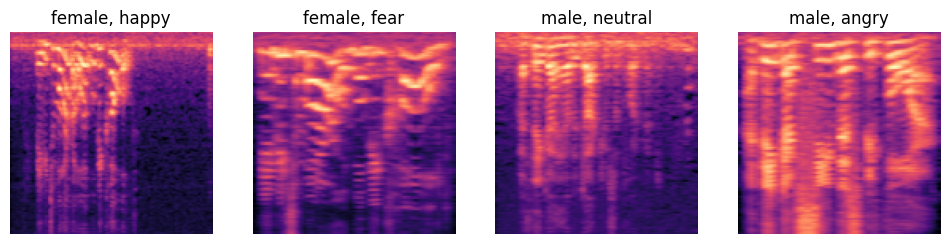

In [8]:
# quick look at a couple of spectrograms just to sanity check
sample_rows = crema_df.sample(4, random_state=1)

plt.figure(figsize=(12, 3))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = audio_to_spectrogram(row["path"])
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap="magma")
    plt.title(f"{row['gender']}, {row['emotion']}")
    plt.axis("off")
plt.show()


In [9]:
SPEC_CACHE = "spectrograms.npy"
META_CACHE = "spectrogram_meta.csv"

all_df = pd.concat([crema_df, ravdess_df], ignore_index=True) if len(ravdess_df) else crema_df.copy()

if os.path.exists(SPEC_CACHE) and os.path.exists(META_CACHE):
    print("loading cached spectrograms")
    X_all = np.load(SPEC_CACHE)
    meta_all = pd.read_csv(META_CACHE)
else:
    imgs = []
    keep_rows = []
    for i, row in all_df.iterrows():
        try:
            imgs.append(audio_to_spectrogram(row["path"]))
            keep_rows.append(row)
        except Exception:
            continue
        if len(imgs) % 500 == 0:
            print(len(imgs), "done")

    X_all = np.stack(imgs).astype("uint8")
    meta_all = pd.DataFrame(keep_rows).reset_index(drop=True)

    np.save(SPEC_CACHE, X_all)
    meta_all.to_csv(META_CACHE, index=False)

print(X_all.shape, len(meta_all))


500 done
1000 done
1500 done
2000 done
2500 done
3000 done
3500 done
4000 done
4500 done
5000 done
5500 done
6000 done
6500 done
7000 done
7500 done
8000 done
8500 done
9000 done
9500 done
(9938, 128, 128) 9938


## Gender CNN

Same block structure as the car colour CNN (Conv2D + MaxPooling a few times, then Dense), just a
smaller input and a single sigmoid output since this is just male vs female.


In [10]:
def actor_split(df, test_frac=0.25, seed=42):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=seed)
    idx_all = np.arange(len(df))
    train_idx, test_idx = next(splitter.split(idx_all, groups=df["actor"].values))
    return train_idx, test_idx


In [11]:
gender_y = (meta_all["gender"] == "male").astype(int).values
train_idx, test_idx = actor_split(meta_all)

Xg_train = X_all[train_idx].reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Xg_test = X_all[test_idx].reshape(-1, IMG_SIZE, IMG_SIZE, 1)
yg_train, yg_test = gender_y[train_idx], gender_y[test_idx]

gender_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

gender_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gender_model.summary()


I0000 00:00:1787749900.055143      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787749900.057941      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,345 (14.13 MB)

 Trainable params: 3,705,345 (14.13 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
gender_history = gender_model.fit(
    Xg_train, yg_train,
    validation_data=(Xg_test, yg_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
 13/232 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5478 - loss: 0.8924

I0000 00:00:1787749906.507251      90 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


232/232 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8737 - loss: 0.2862 - val_accuracy: 0.9089 - val_loss: 0.2327
Epoch 2/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9583 - loss: 0.1114 - val_accuracy: 0.9034 - val_loss: 0.2489
Epoch 3/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9738 - loss: 0.0746 - val_accuracy: 0.9082 - val_loss: 0.2744
Epoch 4/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9835 - loss: 0.0453 - val_accuracy: 0.8923 - val_loss: 0.3481
Epoch 5/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9875 - loss: 0.0357 - val_accuracy: 0.8127 - val_loss: 0.7768
Epoch 6/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9902 - loss: 0.0267 - val_accuracy: 0.9173 - val_loss: 0.3046
Epoch 7/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9920 - loss: 0.0215 - val_accuracy: 0.8666 - val_loss: 0.6116
Epoch 8/10
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9965 - loss: 0.0136 - val_accuracy: 0.91

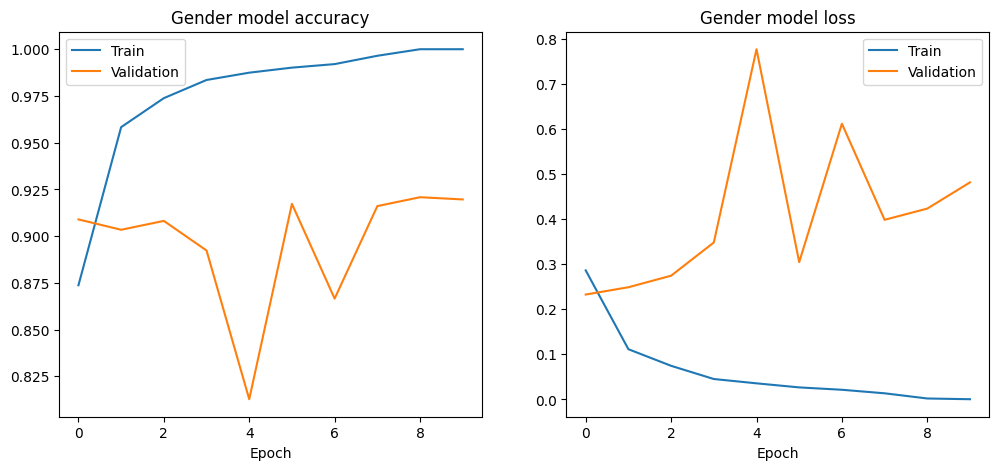

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gender_history.history['accuracy'])
plt.plot(gender_history.history['val_accuracy'])
plt.title('Gender model accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(gender_history.history['loss'])
plt.plot(gender_history.history['val_loss'])
plt.title('Gender model loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()


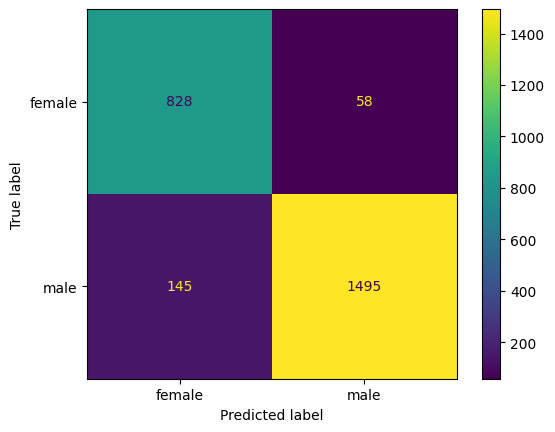

              precision    recall  f1-score   support

      female       0.85      0.93      0.89       886
        male       0.96      0.91      0.94      1640

    accuracy                           0.92      2526
   macro avg       0.91      0.92      0.91      2526
weighted avg       0.92      0.92      0.92      2526



In [14]:
gender_pred = (gender_model.predict(Xg_test, verbose=0) > 0.5).astype(int).ravel()

cm = confusion_matrix(yg_test, gender_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["female", "male"])
disp.plot()
plt.show()

print(classification_report(yg_test, gender_pred, target_names=["female", "male"]))


## Age CNN

This is the one that actually needed real data - trained only on male CREMA-D clips, using their
real ages (20-74). Regression instead of classification, so the last layer is just a single plain
number, no activation.


In [15]:
age_mask = (meta_all["gender"] == "male") & (~meta_all["age"].isna())
age_df = meta_all[age_mask].reset_index(drop=True)
X_age = X_all[age_mask.values]

train_idx_a, test_idx_a = actor_split(age_df)

Xa_train = X_age[train_idx_a].reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Xa_test = X_age[test_idx_a].reshape(-1, IMG_SIZE, IMG_SIZE, 1)
ya_train = age_df["age"].values[train_idx_a]
ya_test = age_df["age"].values[test_idx_a]

n_senior_actors = (age_df.groupby("actor")["age"].first() > 60).sum()
print(f"male clips: {len(age_df)}, actors: {age_df['actor'].nunique()} ({n_senior_actors} over 60)")

age_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)   # plain number = predicted age
])

age_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
age_model.summary()


male clips: 3930, actors: 48 (5 over 60)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,345 (14.13 MB)

 Trainable params: 3,705,345 (14.13 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
age_history = age_model.fit(
    Xa_train, ya_train,
    validation_data=(Xa_test, ya_test),
    epochs=15,
    batch_size=32
)


Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 261.3731 - mae: 12.8180 - val_loss: 204.9932 - val_mae: 12.7706
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 191.3519 - mae: 11.3564 - val_loss: 207.9702 - val_mae: 13.0058
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 183.9773 - mae: 11.0974 - val_loss: 191.9075 - val_mae: 12.1849
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 175.2782 - mae: 10.8727 - val_loss: 473.7795 - val_mae: 19.3405
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 175.5834 - mae: 10.8390 - val_loss: 207.3561 - val_mae: 13.0878
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 152.4529 - mae: 10.1221 - val_loss: 205.5071 - val_mae: 10.6383
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 147.0342 - mae: 9.8164 - val_loss: 264.9799 - val_mae: 14.5817
Epoch 8/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 123.4124 - mae: 9.0205 - val_loss: 203.6382 - val_mae: 11.1441
Epoch 9/15
93/93 ━

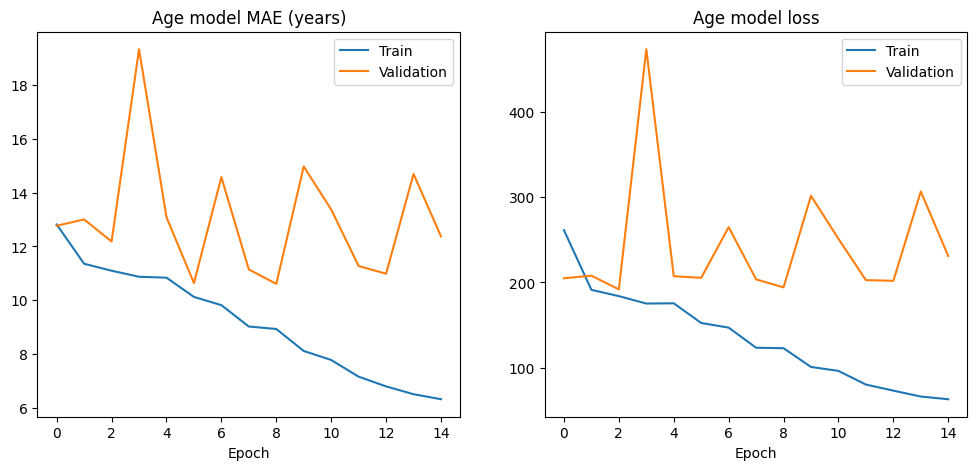

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(age_history.history['mae'])
plt.plot(age_history.history['val_mae'])
plt.title('Age model MAE (years)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(age_history.history['loss'])
plt.plot(age_history.history['val_loss'])
plt.title('Age model loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()


In [18]:
age_pred = age_model.predict(Xa_test, verbose=0).ravel()

print("MAE:", round(mean_absolute_error(ya_test, age_pred), 1), "years")
print("R2:", round(r2_score(ya_test, age_pred), 3))

senior_true = ya_test > 60
senior_pred = age_pred > 60
print("senior (60+) accuracy from the regressor:", round((senior_true == senior_pred).mean(), 3))


MAE: 12.4 years
R2: -0.251
senior (60+) accuracy from the regressor: 0.905


## Emotion CNN

Trained on CREMA-D (+ RAVDESS if you added it), 6 classes. Same 3-conv-block pattern as the car
colour CNN, just with a different input size.


In [19]:
emotion_classes = sorted(meta_all["emotion"].dropna().unique())
emotion_to_idx = {e: i for i, e in enumerate(emotion_classes)}
print(emotion_classes)

emo_mask = meta_all["emotion"].isin(emotion_classes)
emo_df = meta_all[emo_mask].reset_index(drop=True)
X_emo = X_all[emo_mask.values]
y_emo = emo_df["emotion"].map(emotion_to_idx).values

train_idx_e, test_idx_e = actor_split(emo_df)

Xe_train = X_emo[train_idx_e].reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Xe_test = X_emo[test_idx_e].reshape(-1, IMG_SIZE, IMG_SIZE, 1)
ye_train, ye_test = y_emo[train_idx_e], y_emo[test_idx_e]

emotion_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(emotion_classes), activation='softmax')
])

emotion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
emotion_model.summary()


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,838 (12.61 MB)

 Trainable params: 3,304,838 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
emotion_history = emotion_model.fit(
    Xe_train, ye_train,
    validation_data=(Xe_test, ye_test),
    epochs=15,
    batch_size=32
)


Epoch 1/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3191 - loss: 1.6199 - val_accuracy: 0.3844 - val_loss: 1.5340
Epoch 2/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4856 - loss: 1.3071 - val_accuracy: 0.4596 - val_loss: 1.4066
Epoch 3/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5688 - loss: 1.1262 - val_accuracy: 0.4703 - val_loss: 1.5823
Epoch 4/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6314 - loss: 0.9840 - val_accuracy: 0.4790 - val_loss: 1.5175
Epoch 5/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6887 - loss: 0.8407 - val_accuracy: 0.4873 - val_loss: 1.5796
Epoch 6/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7446 - loss: 0.6901 - val_accuracy: 0.4584 - val_loss: 1.8083
Epoch 7/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7992 - loss: 0.5458 - val_accuracy: 0.4905 - val_loss: 1.9784
Epoch 8/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8600 - loss: 0.3957 - val_acc

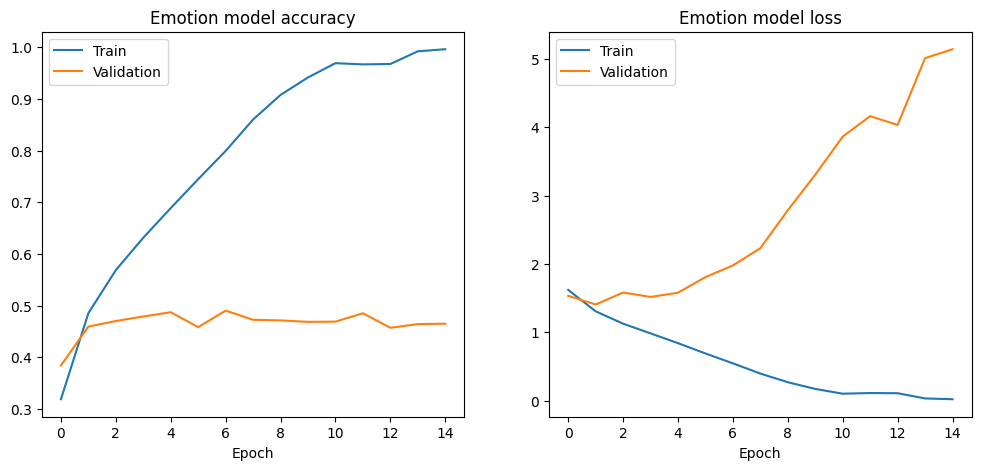

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(emotion_history.history['accuracy'])
plt.plot(emotion_history.history['val_accuracy'])
plt.title('Emotion model accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(emotion_history.history['loss'])
plt.plot(emotion_history.history['val_loss'])
plt.title('Emotion model loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()


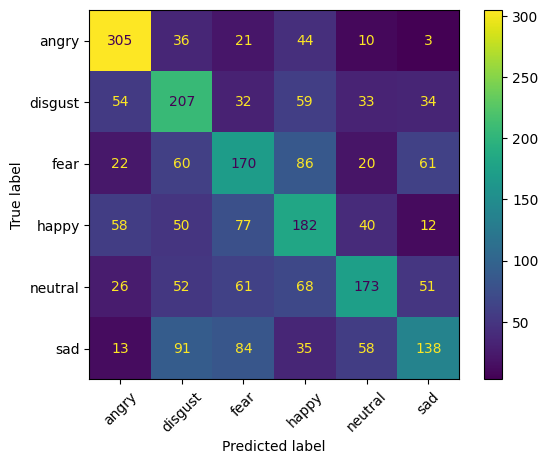

              precision    recall  f1-score   support

       angry       0.64      0.73      0.68       419
     disgust       0.42      0.49      0.45       419
        fear       0.38      0.41      0.39       419
       happy       0.38      0.43      0.41       419
     neutral       0.52      0.40      0.45       431
         sad       0.46      0.33      0.38       419

    accuracy                           0.47      2526
   macro avg       0.47      0.47      0.46      2526
weighted avg       0.47      0.47      0.46      2526



In [22]:
emo_pred = np.argmax(emotion_model.predict(Xe_test, verbose=0), axis=1)

cm = confusion_matrix(ye_test, emo_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_classes)
disp.plot(xticks_rotation=45)
plt.show()

print(classification_report(ye_test, emo_pred, target_names=emotion_classes))


## Save the models

In [23]:
gender_model.save("gender_cnn.keras")
age_model.save("age_cnn.keras")
emotion_model.save("emotion_cnn.keras")

In [24]:
import numpy as np

def best_and_final(history, metric="accuracy"):
    val = history.history[f"val_{metric}"]
    best_epoch = int(np.argmax(val)) + 1
    return best_epoch, val[best_epoch - 1], val[-1]

print("Gender Classification")
g_epoch, g_best, g_final = best_and_final(gender_history)
print(f"Validation Accuracy: ~{g_final*100:.0f}% "
      f"(peaked around {g_best*100:.1f}% near epoch {g_epoch}, final epoch {g_final*100:.2f}%)")
print(f"Model size: {gender_model.count_params():,} parameters")

print()
print("Age Estimation")
n_actors = age_df["actor"].nunique()
print(f"Trained on {len(age_df)} male voice clips from {n_actors} actors "
      f"(only {n_senior_actors} of whom are over 60).")
mae = mean_absolute_error(ya_test, age_pred)
r2 = r2_score(ya_test, age_pred)
senior_acc = (senior_true == senior_pred).mean()
print(f"Test MAE: {mae:.1f} years")
print(f"Test R-squared: {r2:.2f} "
      f"({'negative, due to the very small number of senior training examples' if r2 < 0 else 'positive'})")
print(f"Senior Citizen (60+) Threshold Accuracy: {senior_acc*100:.1f}%")

print()
print("Emotion Detection")
print(f"{len(emotion_classes)}-way classification ({', '.join(emotion_classes)}).")
e_epoch, e_best, e_final = best_and_final(emotion_history)
print(f"Validation Accuracy: ~{min(e_final,e_best)*100:.0f}-{max(e_final,e_best)*100:.0f}% "
      f"(peaked around {e_best*100:.1f}% near epoch {e_epoch}, final epoch {e_final*100:.2f}%, "
      f"after which the model begins to overfit)")

Gender Classification
Validation Accuracy: ~92% (peaked around 92.1% near epoch 9, final epoch 91.96%)
Model size: 3,705,345 parameters

Age Estimation
Trained on 3930 male voice clips from 48 actors (only 5 of whom are over 60).
Test MAE: 12.4 years
Test R-squared: -0.25 (negative, due to the very small number of senior training examples)
Senior Citizen (60+) Threshold Accuracy: 90.5%

Emotion Detection
6-way classification (angry, disgust, fear, happy, neutral, sad).
Validation Accuracy: ~47-49% (peaked around 49.0% near epoch 7, final epoch 46.52%, after which the model begins to overfit)


In [25]:
def analyze_voice(audio_path):
    img = audio_to_spectrogram(audio_path)
    x = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    gender_prob = float(gender_model.predict(x, verbose=0)[0][0])
    gender = "male" if gender_prob > 0.5 else "female"
    gender_conf = gender_prob if gender == "male" else 1 - gender_prob

    if gender != "male":
        return "Upload male voice."

    age_pred = float(age_model.predict(x, verbose=0)[0][0])
    age_pred = max(15.0, min(95.0, age_pred))
    is_senior = age_pred > 60

    lines = [
        "Gender: Male",
        f"Estimated Age: {age_pred:.1f}",
        f"Senior Citizen: {'Yes' if is_senior else 'No'}",
    ]

    if is_senior:
        emo_probs = emotion_model.predict(x, verbose=0)[0]
        top = int(np.argmax(emo_probs))
        lines.append(f"Detected Emotion: {emotion_classes[top]}")

    return "\n".join(lines)

# quick self test
print(analyze_voice(crema_df.iloc[0]["path"]))

Upload male voice.


## GUI

Same Gradio setup as the car project, just audio input instead of an image, with a mic option so you
can record straight from the browser too.


In [26]:
demo = gr.Interface(
    fn=analyze_voice,
    inputs=gr.Audio(type="filepath", label="Upload or record a voice note"),
    outputs=gr.Textbox(label="Result", lines=8),
    title="Voice Age & Emotion Detector",
    description="Male voices only. Ages over 60 additionally get emotion detection."
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://abb3d12888b684580a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Future Improvements

- Support for multiple languages
- Real-time microphone input
- Improved emotion categories
- Larger training datasets
- Mobile and web deployment


## Conclusion

The project demonstrates how audio signals can be transformed into image representations and analyzed using CNNs to predict age and emotion. By combining audio preprocessing, deep learning, and an interactive Gradio interface, the system provides an effective end-to-end solution for voice-based analysis.